### 1. Import Dependencies

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2.Basic information

In [58]:
df = pd.read_csv("data/raw/Cafe_sales.csv")
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


- **df.info()** - only counts actual NaN values - it doesn't recognize text like "UNKNOWN", "ERROR", or empty strings as missing values
- All columns show **object** dtype - this means pandas is treating everything as text, including numbers


In [60]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

#### To get accurate missing value counts

In [61]:
df.replace(['UNKNOWN', 'ERROR', '', 'NULL', 'N/A','<NA>'], pd.NA, inplace=True)
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [62]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,<NA>,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,<NA>,<NA>,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


#### fix data types:

In [63]:
# Convert numeric columns
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [64]:
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              9031 non-null   object 
 2   Quantity          9521 non-null   float64
 3   Price Per Unit    9467 non-null   float64
 4   Total Spent       9498 non-null   float64
 5   Payment Method    6822 non-null   object 
 6   Location          6039 non-null   object 
 7   Transaction Date  9540 non-null   object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB


### 3. Handle Missing Values

In [66]:
df.head(30)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,<NA>,<NA>,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,<NA>,3.0,3.0,9.0,<NA>,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,<NA>,2023-10-28
8,TXN_4717867,NaN,5.0,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,NaN,In-store,2023-12-31


#### 3.1 Impute

##### 3.1.2 Item & Price Per Unit Columns

In [67]:
df["Item"].value_counts()

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64

In [68]:
# check if there is unique Price Per Unit for Items
df_copy = df.copy()
df_clean = df_copy.dropna(subset=['Item', 'Price Per Unit']) # Removes all rows where either 'Item' OR 'Price Per Unit' is null
item_prices = df_clean.groupby("Item")["Price Per Unit"].unique()
item_prices

# Apply different functions to different columns
# df.groupby('Price Per Unit').agg({
#     'Item': 'unique',
#     'Quantity': 'mean',
#     'Total Spent': 'sum'
# })

Item
Cake        [3.0]
Coffee      [2.0]
Cookie      [1.0]
Juice       [3.0]
Salad       [5.0]
Sandwich    [4.0]
Smoothie    [4.0]
Tea         [1.5]
Name: Price Per Unit, dtype: object

In [69]:
# Fill Item and Price Per Unit  (only one column consists NULL value)

# Step 1: Remove only rows where BOTH Item AND Price are null
df_clean = df.dropna(subset=['Item', 'Price Per Unit'], how='all').copy()

# Step 2: Create mappings from rows that have BOTH values
complete_rows = df_clean.dropna(subset=['Item', 'Price Per Unit'])
item_to_price = dict(complete_rows.groupby('Item')['Price Per Unit'].first())
price_to_item = dict(complete_rows.groupby('Price Per Unit')['Item'].first())

# # Step 3: Fill nulls - keep filling until no more can be filled
df_clean['Item'] = df_clean['Item'].fillna(df_clean['Price Per Unit'].map(price_to_item))
df_clean['Price Per Unit'] = df_clean['Price Per Unit'].fillna(df_clean['Item'].map(item_to_price))

# Price Per Unit    .map(price_to_item)    →    Result
# 2.0              →  price_to_item[2.0]   →    'Coffee'
# 3.0              →  price_to_item[3.0]   →    'Cake'  
# 1.0              →  price_to_item[1.0]   →    'Cookie'
# NaN              →  price_to_item[NaN]   →    NaN (no mapping)

In [70]:
df_clean.isnull().sum()

Transaction ID         0
Item                   0
Quantity             476
Price Per Unit         0
Total Spent          499
Payment Method      3157
Location            3936
Transaction Date     457
dtype: int64

In [71]:
remove_rows = len(df) - len(df_clean)
remove_rows

54

**Remove 54** columns Because They Both Item and Price Per Unit consists of Null Value

In [72]:
df_clean.isnull().sum()

Transaction ID         0
Item                   0
Quantity             476
Price Per Unit         0
Total Spent          499
Payment Method      3157
Location            3936
Transaction Date     457
dtype: int64

##### 3.1.2 Quantity and Total Spent Columns

In [73]:
df_clean.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,<NA>,<NA>,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,Cake,3.0,3.0,9.0,<NA>,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,<NA>,2023-10-28
8,TXN_4717867,Cake,5.0,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,NaN,In-store,2023-12-31


In [74]:

# Remove rows where both Quantity and Total Spent are null
df_clean = df_clean.dropna(subset=['Quantity', 'Total Spent'], how='all')

# Fill missing values using vectorized operations
df_clean['Total Spent'] = df_clean['Total Spent'].fillna(df_clean['Quantity'] * df_clean['Price Per Unit'])
df_clean['Quantity'] = df_clean['Quantity'].fillna(df_clean['Total Spent'] / df_clean['Price Per Unit'])


In [75]:
len(df)-len(df_clean)

74

- Now have to remove **20 rows** because of Total spent and Quantity both consists of NULL values in same row
- 54 + 20 = 74

In [76]:
df_clean.isnull().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      3150
Location            3930
Transaction Date     457
dtype: int64

##### 3.1.3 Payment Method Column

In [77]:
df_clean["Payment Method"].value_counts()

Payment Method
Digital Wallet    2277
Credit Card       2253
Cash              2246
Name: count, dtype: int64

<Axes: ylabel='count'>

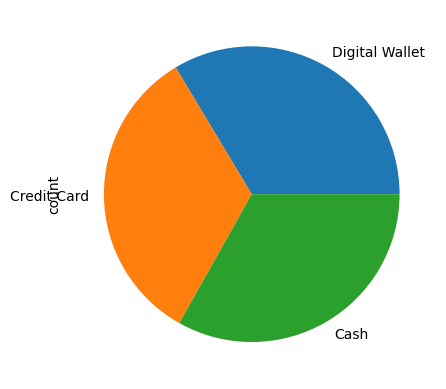

In [78]:
df_clean["Payment Method"].value_counts().plot(kind="pie")

**Random Imputation**
- Since payment methods are fairly evenly distributed

In [79]:
# Calculate proportions
proportions = df_clean['Payment Method'].value_counts(normalize=True)

# Fill missing values randomly based on existing distribution
missing_mask = df_clean['Payment Method'].isnull()
print(missing_mask)
df_clean.loc[missing_mask, 'Payment Method'] = np.random.choice(
    proportions.index, 
    size=missing_mask.sum(), 
    p=proportions.values
)

0       False
1       False
2       False
3        True
4       False
        ...  
9994     True
9995     True
9997    False
9998    False
9999    False
Name: Payment Method, Length: 9926, dtype: bool


In [80]:
df_clean.isnull().sum()

Transaction ID         0
Item                   0
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method         0
Location            3930
Transaction Date     457
dtype: int64

##### 3.1.3 Location Column

In [81]:
df["Location"].value_counts()

Location
Takeaway    3022
In-store    3017
Name: count, dtype: int64

In [82]:
proportions = df_clean["Location"].value_counts(normalize=True)
missing_mask = df_clean["Location"].isnull()

df_clean.loc[missing_mask,"Location"] = np.random.choice(
    proportions.index,
    size = missing_mask.sum(),
    p = proportions.values
)

In [83]:
df_clean.isnull().sum()

Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    457
dtype: int64

##### 3.1.4 Transaction Date Column

**"I have no plan with analyze trends over time"** so i dropped the column
-  if i want this can use removing null rows

### 4. Drop columns

In [84]:
df_clean.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [85]:
remove_columns = ["Transaction ID","Transaction Date"]
df_clean = df_clean.drop(remove_columns,axis=1)
df_clean

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
0,Coffee,2.0,2.0,4.0,Credit Card,Takeaway
1,Cake,4.0,3.0,12.0,Cash,In-store
2,Cookie,4.0,1.0,4.0,Credit Card,In-store
3,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway
4,Coffee,2.0,2.0,4.0,Digital Wallet,In-store
...,...,...,...,...,...,...
9994,Smoothie,4.0,4.0,16.0,Digital Wallet,Takeaway
9995,Coffee,2.0,2.0,4.0,Cash,Takeaway
9997,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway
9998,Cookie,3.0,1.0,3.0,Digital Wallet,In-store


In [86]:
df_clean.isnull().sum()

Item              0
Quantity          0
Price Per Unit    0
Total Spent       0
Payment Method    0
Location          0
dtype: int64

In [87]:
len(df)-len(df_clean)

74

In [88]:
df_clean.to_csv("data/processed/Cafe_sales_Missing_Values_Handled.csv",index=False)